# ML Model Comparison: Linear Regression, Logistic Regression & Naive Bayes


Read Replace every `# TODO` with your own code and answer every **Q** in a markdown cell.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics

RANDOM_STATE = 42

## Part 0 — Load & explore `student_performance.csv`

In [2]:
df = pd.read_csv('data/student_performance.csv')
df.head()

,student_id,gender,study_hours_per_day,attendance_pct,sleep_hours,previous_score,internet_access,private_tuition,extracurriculars,final_score,result
0,1,M,7.7,53.1,5.8,52.8,Yes,No,3,59.3,Fail
1,2,F,4.4,72.9,8.1,71.4,No,Yes,1,60.2,Pass
2,3,F,8.6,56.5,5.6,66.4,Yes,No,1,73.6,Pass
3,4,M,7.0,57.6,6.7,67.2,Yes,No,3,60.6,Pass
4,5,M,0.9,81.6,6.3,88.4,Yes,Yes,1,61.5,Pass


In [3]:
# TODO: df.info(), df.describe(), count missing values per column
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           1000 non-null   int64  
 1   gender               1000 non-null   str    
 2   study_hours_per_day  1000 non-null   float64
 3   attendance_pct       985 non-null    float64
 4   sleep_hours          985 non-null    float64
 5   previous_score       985 non-null    float64
 6   internet_access      1000 non-null   str    
 7   private_tuition      1000 non-null   str    
 8   extracurriculars     1000 non-null   int64  
 9   final_score          1000 non-null   float64
 10  result               1000 non-null   str    
dtypes: float64(5), int64(2), str(4)
memory usage: 86.1 KB


student_id              0
gender                  0
study_hours_per_day     0
attendance_pct         15
sleep_hours            15
previous_score         15
internet_access         0
private_tuition         0
extracurriculars        0
final_score             0
result                  0
dtype: int64

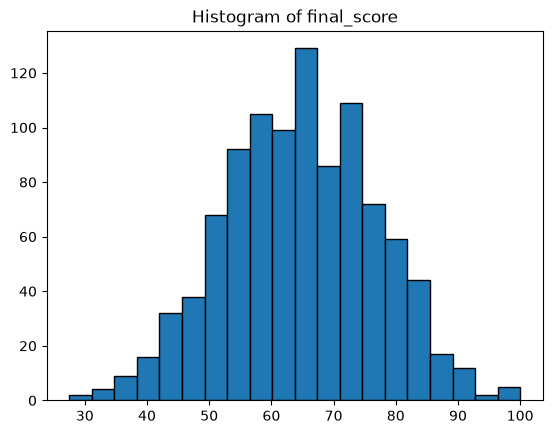

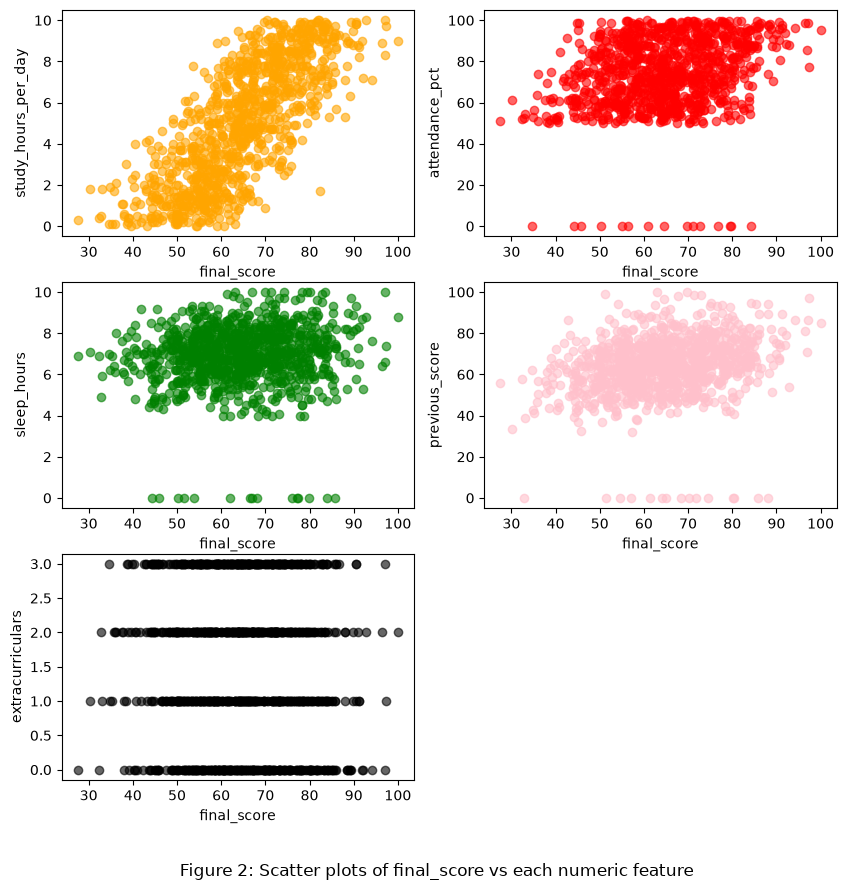

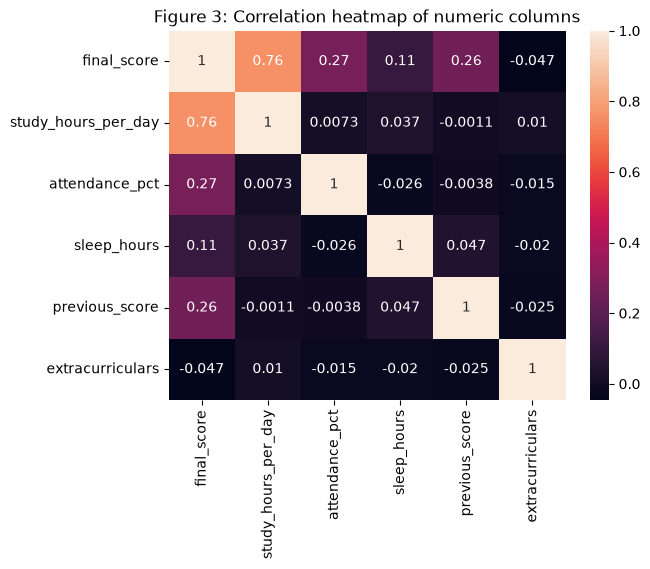

In [28]:
# TODO: histogram of final_score; scatter plots of final_score vs each numeric feature
plt.title("Histogram of final_score")
plt.hist(df['final_score'], bins=20, edgecolor="black")
plt.show()

final = df['final_score']
data = ['study_hours_per_day', 'attendance_pct', 'sleep_hours', 'previous_score', 'extracurriculars']
colors = ['orange', 'red', 'green', 'pink', 'black']

sleep_filled = df['sleep_hours'].fillna(df.sleep_hours.mean())
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for ax, ylab, c in zip(axes.flat, data, colors):
    x = sleep_filled if ylab == "sleep_hours" else df[ylab].fillna(0)
    ax.scatter(final, x, color=c, alpha=0.6)
    ax.set_xlabel("final_score")
    ax.set_ylabel(ylab)
axes.flat[-1].axis("off")
fig.supxlabel("Figure 2: Scatter plots of final_score vs each numeric feature")
plt.show()
# TODO: correlation heatmap of numeric columns (sns.heatmap)
dffinal = df[['final_score', *data]].fillna(0)
sns.heatmap(data=dffinal.corr(), annot=True)
plt.title("Figure 3: Correlation heatmap of numeric columns")
plt.show()

**Q0.** Which feature looks most related to `final_score`? Are there missing values, and how will you handle them?

Ans:- The feature that looks most related to `final_score` is `study_hours_per_day`, as per the scatterplot in top right in figure 2, and in figure 3. as w.r.t `study_hourse_per_day`, `final_score` gets more higher value.

There are some missing values as in `attendance_pct=15`, `sleep_hours=15` and `previous_score=15`, we filled the missing values for `attendance_pct` and `previous_score` with `0` as both can be 0 respectively and we filled `sleep_hours` with the mean of the same column as sleep hours cann't be `0`.

## Preprocessing (shared by Parts A & B)

In [ ]:
num = ['study_hours_per_day', 'attendance_pct', 'sleep_hours', 'previous_score', 'extracurriculars']
cat = ['gender', 'internet_access', 'private_tuition']

# TODO: build a ColumnTransformer:
#   numeric -> SimpleImputer(median) + StandardScaler
#   categorical -> OneHotEncoder(drop='if_binary')
pre = None
X = df[num + cat]

## Part A — Linear Regression: predict `final_score`

In [ ]:
y = df['final_score']
# TODO: 80/20 train_test_split with random_state=RANDOM_STATE


In [ ]:
# A1. Simple linear regression using ONLY study_hours_per_day
# TODO: fit, report R², plot data + fitted line


In [ ]:
# A2. Multiple linear regression with all features (Pipeline: pre -> LinearRegression)
# TODO: report MAE, RMSE, R² on the test set


In [ ]:
# A3. TODO: table of coefficients (use pre.get_feature_names_out()), sorted
# A4. TODO: Actual-vs-Predicted plot and Residuals-vs-Predicted plot


**Q-A.** (1) Interpret the top 3 coefficients in plain English. Why did we scale features before comparing them?
(2) How much did R² improve from A1 to A2? (3) Do the residuals look random? What would a pattern mean?

## Part B — Logistic Regression: predict `result` (Pass/Fail)
⚠️ Do **not** use `final_score` as a feature — explain why in Q-B.

In [ ]:
yb = (df['result'] == 'Pass').astype(int)
# TODO: stratified 80/20 split


In [ ]:
# B1. TODO: Pipeline(pre -> LogisticRegression(max_iter=1000)); fit
# B2. TODO: accuracy, precision, recall, F1, ROC-AUC, confusion matrix, ROC curve


In [ ]:
# B3. TODO: odds ratios = np.exp(coef_); sorted table
# B4. TODO: precision & recall at thresholds 0.3, 0.5, 0.7 using predict_proba


**Q-B.** (1) Why would using `final_score` be cheating (target leakage)? (2) Interpret the largest odds ratio.
(3) If the college wants to catch *every* at-risk (Fail) student for remedial classes, which threshold and which metric matter most?

## Part C — Naive Bayes: SMS spam filter (`sms_spam.csv`)

In [ ]:
sms = pd.read_csv('data/sms_spam.csv')
# TODO: class counts, average message length per class, 5 sample messages of each class


In [ ]:
ys = (sms.label == 'spam').astype(int)
# TODO: stratified 80/20 split of sms.message


In [ ]:
# C1. TODO: Pipeline(CountVectorizer -> MultinomialNB); report accuracy, precision, recall, F1, confusion matrix
# C2. TODO: compare CountVectorizer vs TfidfVectorizer and alpha in [0.01, 0.1, 1, 5] -> results table


In [ ]:
# C3. TODO: top 10 'spam' and 'ham' words using nb.feature_log_prob_[1] - nb.feature_log_prob_[0]
# C4. TODO: classify 5 messages you write yourself; 5-fold cross_val_score (scoring='f1')


In [ ]:
# C5. TODO: train LogisticRegression on the same CountVectorizer features and compare F1


**Q-C.** (1) What is the 'naive' assumption, and why does NB still work well for text? (2) What does `alpha` (Laplace smoothing) do?
(3) For a spam filter, is a false positive or a false negative worse? Which metric would you optimise?
(4) Look at 3 misclassified messages — why did the model get them wrong?

## Part D — Comparison & Conclusion
**TODO:** Fill a summary table (model, task, best metric) and write 150–200 words: when would you choose each algorithm?